In [6]:
import random
import numpy as np
import tensorflow as tf

random.seed(0)
np.random.seed(0)
tf.random.set_seed(0)

In [7]:
#### importing the dependencies

In [8]:
import os
import json
from zipfile import ZipFile
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

In [9]:
## UPLOAD THE KAGGLE.JSON FILE

In [10]:
!pip install kaggle


In [11]:
# configuring the path of Kaggle.json file
!mkdir -p ~/.kaggle
!cp "/Users/harshitdubey/Downloads/kaggle (2).json" ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

In [12]:
#Importing Face Mask Dataset
## API to fetch the dataset from Kaggle
!kaggle datasets download -d abdallahalidev/plantvillage-dataset

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
plantvillage-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [13]:
!ls

anaconda_projects
ASS1_MSD_HARSHIT_250920.py
books-project
Breast Cancer Classification with Neural Network.ipynb
class_indices.json
data
data.csv
Desktop
Documents
Downloads
dubey ji
EXERCISE 1.1(GROUP= B).ipynb
Face Mask Detection using CNN(Deep Learning System).ipynb
face-mask-dataset.zip
Group B.ipynb
HARSHIT DUBEY(PYTHON ASSIGNMENT).py
harshit.csv
HEART DISEASE PREDICTION MODEL.ipynb
Housing Price Prediction.ipynb
Library
LOAN PREDICTION MODEL.ipynb
MNIST Handwritten Digit Clasification using Deep Learning (Neural Network.ipynb
MNIST Handwritten Digit Clasification using Deep Learning (Neural Network).ipynb
Movies
Music
patient_data.csv
Pictures
PLANT DISEASE PROJECT
plant_disease_prediction_model.h5
plantvillage dataset
plantvillage-dataset.zip
Public
PyCharmMiscProject
r
r programming.18
r-programming
Sonar Rock vs Mine Prediction Model.ipynb
sonar_rock_mine_model.pkl
Untitled.html
Untitled.ipynb
Untitled.Rmd
Untitled1.ipynb
Untitled10-Copy1.ipynb
Untitled10.ipynb
Untitled11.ipy

In [14]:
## unzip the download datset
with ZipFile("plantvillage-dataset.zip", 'r') as zip_ref:
    zip_ref.extractall()
    

In [15]:
!ls

anaconda_projects
ASS1_MSD_HARSHIT_250920.py
books-project
Breast Cancer Classification with Neural Network.ipynb
class_indices.json
data
data.csv
Desktop
Documents
Downloads
dubey ji
EXERCISE 1.1(GROUP= B).ipynb
Face Mask Detection using CNN(Deep Learning System).ipynb
face-mask-dataset.zip
Group B.ipynb
HARSHIT DUBEY(PYTHON ASSIGNMENT).py
harshit.csv
HEART DISEASE PREDICTION MODEL.ipynb
Housing Price Prediction.ipynb
Library
LOAN PREDICTION MODEL.ipynb
MNIST Handwritten Digit Clasification using Deep Learning (Neural Network.ipynb
MNIST Handwritten Digit Clasification using Deep Learning (Neural Network).ipynb
Movies
Music
patient_data.csv
Pictures
PLANT DISEASE PROJECT
plant_disease_prediction_model.h5
plantvillage dataset
plantvillage-dataset.zip
Public
PyCharmMiscProject
r
r programming.18
r-programming
Sonar Rock vs Mine Prediction Model.ipynb
sonar_rock_mine_model.pkl
Untitled.html
Untitled.ipynb
Untitled.Rmd
Untitled1.ipynb
Untitled10-Copy1.ipynb
Untitled10.ipynb
Untitled11.ipy

In [16]:
import os

print(os.listdir("plantvillage dataset"))

print(len(os.listdir("plantvillage dataset/segmented")))
print(os.listdir("plantvillage dataset/segmented")[:5])

print(len(os.listdir("plantvillage dataset/color")))
print(os.listdir("plantvillage dataset/color")[:5])

print(len(os.listdir("plantvillage dataset/grayscale")))
print(os.listdir("plantvillage dataset/grayscale")[:5])

['grayscale', 'segmented', 'color']
38
['Strawberry___healthy', 'Grape___Black_rot', 'Potato___Early_blight', 'Blueberry___healthy', 'Corn_(maize)___healthy']
38
['Strawberry___healthy', 'Grape___Black_rot', 'Potato___Early_blight', 'Blueberry___healthy', 'Corn_(maize)___healthy']
38
['Strawberry___healthy', 'Grape___Black_rot', 'Potato___Early_blight', 'Blueberry___healthy', 'Corn_(maize)___healthy']


In [17]:
## above code se ye pata chal raha hai ki data set folder me 3 subfolder hai grayscale(balck and white image),segmented(jinka koi bacground coloure na ho),color(rgb image)
## and teeno me same 38 type ke palnt disease hai (38 categories)

In [18]:
### NUMBER OF CLASS = 38

In [19]:
print(len(os.listdir("plantvillage dataset/color/Grape___healthy")))
print(os.listdir("plantvillage dataset/color/Grape___healthy")[:5])

423
['04991ee7-b17c-420f-90ff-230d4e59361a___Mt.N.V_HL 9055.JPG', 'e949f6bb-cda7-4824-9a97-67337fc164a5___Mt.N.V_HL 6156.JPG', 'bd88082c-b059-4087-88f4-b6ba9cbf07aa___Mt.N.V_HL 6124.JPG', '59ecd16e-8136-4295-93e4-0dc8755f48eb___Mt.N.V_HL 6133.JPG', '215c8317-c0ca-4b35-9ac2-28e01712e367___Mt.N.V_HL 8914.JPG']


In [20]:
## DATA PREPROCESSING


In [21]:
##DATASET PATH
base_dir = 'plantvillage dataset/color'

(256, 256, 3)


<function matplotlib.pyplot.show(close=None, block=None)>

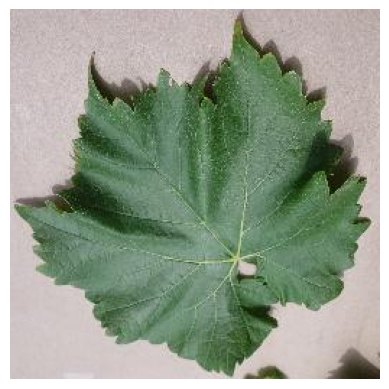

In [22]:
image_path = "plantvillage dataset/color/Grape___healthy/e949f6bb-cda7-4824-9a97-67337fc164a5___Mt.N.V_HL 6156.JPG"

##read the image
img = mpimg.imread(image_path)

print(img.shape)

#display the image
plt.imshow(img)
plt.axis('off')
plt.show

In [23]:
image_path = "plantvillage dataset/color/Grape___healthy/e949f6bb-cda7-4824-9a97-67337fc164a5___Mt.N.V_HL 6156.JPG"

##read the image
img = mpimg.imread(image_path)
print(img)


[[[198 186 186]
  [183 171 171]
  [190 178 178]
  ...
  [182 168 165]
  [181 167 164]
  [187 173 170]]

 [[199 187 187]
  [192 180 180]
  [201 189 189]
  ...
  [183 169 166]
  [183 169 166]
  [182 168 165]]

 [[187 175 175]
  [191 179 179]
  [205 193 193]
  ...
  [183 169 166]
  [185 171 168]
  [179 165 162]]

 ...

 [[205 195 194]
  [204 194 193]
  [203 193 192]
  ...
  [ 48  38  26]
  [ 51  41  29]
  [ 51  41  29]]

 [[206 196 195]
  [203 193 192]
  [202 192 191]
  ...
  [ 49  41  28]
  [ 51  41  29]
  [ 49  39  27]]

 [[206 196 195]
  [203 193 192]
  [201 191 190]
  ...
  [ 43  35  22]
  [ 45  35  23]
  [ 40  30  18]]]


In [24]:
# image data generators
img_size = 224
batch_size = 32


In [25]:
## train test split

In [26]:
## image data generator
# Image Data Generator
data_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)


In [27]:
# Train Generator
train_generator = data_gen.flow_from_directory(
    base_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    subset='training',
    class_mode='categorical'
)

Found 43456 images belonging to 38 classes.


In [28]:
# Validation Generator
validation_generator = data_gen.flow_from_directory(
    base_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    subset='validation',
    class_mode='categorical'
)

Found 10849 images belonging to 38 classes.


In [29]:
## CONVOLUTIONAL NEURAL NETWORK

In [30]:
# Model Definition
model = models.Sequential()

model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(img_size, img_size, 3)))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dense(train_generator.num_classes, activation='softmax'))

/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [31]:
## MODEL SUMMARY
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    47,776,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,805,158 (182.36 MB)

 Trainable params: 47,805,158 (182.36 MB)

 Non-trainable params: 0 (0.00 B)

In [51]:
# Compile the Model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [52]:
# Training the Model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=5,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size
)

Epoch 1/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 536s 394ms/step - accuracy: 0.7463 - loss: 0.9076 - val_accuracy: 0.8666 - val_loss: 0.4245
Epoch 2/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 623s 459ms/step - accuracy: 0.9190 - loss: 0.2521 - val_accuracy: 0.8648 - val_loss: 0.4302
Epoch 3/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 723s 533ms/step - accuracy: 0.9623 - loss: 0.1168 - val_accuracy: 0.8655 - val_loss: 0.5527
Epoch 4/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 634s 467ms/step - accuracy: 0.9755 - loss: 0.0763 - val_accuracy: 0.8770 - val_loss: 0.5009
Epoch 5/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 682s 502ms/step - accuracy: 0.9793 - loss: 0.0677 - val_accuracy: 0.8850 - val_loss: 0.5829


In [32]:
## model evaluation

In [53]:

print("Evaluating model...")

val_loss, val_accuracy = model.evaluate(
    validation_generator,
    steps=validation_generator.samples // batch_size
)

print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")

Evaluating model...
339/339 ━━━━━━━━━━━━━━━━━━━━ 38s 113ms/step - accuracy: 0.8850 - loss: 0.5829
Validation Loss: 0.5829
Validation Accuracy: 88.50%


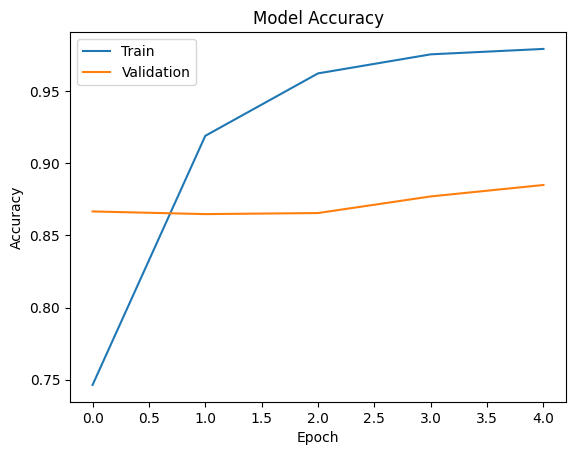

In [54]:
# Plot training & validation accuracy
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

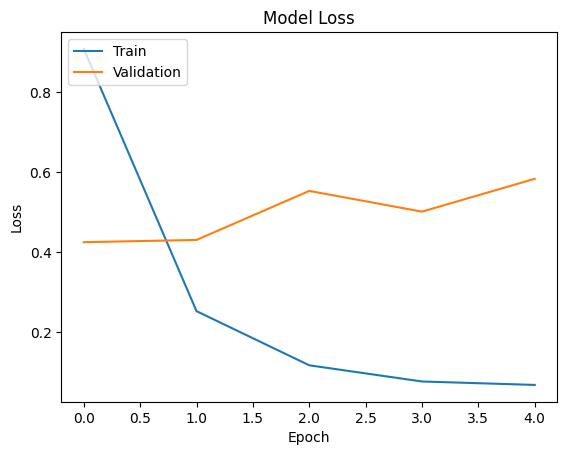

In [55]:
# Plot training & validation loss

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [56]:
## BULIDING A PREDICTIVE SYSTEM

In [57]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Function to load and preprocess image
def load_and_preprocess_image(image_path, target_size=(224, 224)):
    # image open karo
    img = Image.open(image_path)

    # RGB me convert karo
    img = img.convert('RGB')

    # resize karo
    img = img.resize(target_size)

    # numpy array me convert karo
    img_array = np.array(img)

    # values ko 0-1 ke beech scale karo
    img_array = img_array.astype('float32') / 255.0

    # batch dimension add karo: (1, 224, 224, 3)
    img_array = np.expand_dims(img_array, axis=0)

    return img_array

    # Function to predict image class
def predict_image_class(model, image_path, class_indices):
    preprocessed_img = load_and_preprocess_image(image_path)

    predictions = model.predict(preprocessed_img)

    predicted_class_index = np.argmax(predictions, axis=1)[0]

    predicted_class_name = class_indices[predicted_class_index]

    return predicted_class_name

In [58]:
### CREATE A MAPPING FROM CLASS INDICES TO CLASS NAMES
class_indices = {v: k for k, v in train_generator.class_indices.items()}

In [59]:
class_indices

{0: 'Apple___Apple_scab',
 1: 'Apple___Black_rot',
 2: 'Apple___Cedar_apple_rust',
 3: 'Apple___healthy',
 4: 'Blueberry___healthy',
 5: 'Cherry_(including_sour)___Powdery_mildew',
 6: 'Cherry_(including_sour)___healthy',
 7: 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 8: 'Corn_(maize)___Common_rust_',
 9: 'Corn_(maize)___Northern_Leaf_Blight',
 10: 'Corn_(maize)___healthy',
 11: 'Grape___Black_rot',
 12: 'Grape___Esca_(Black_Measles)',
 13: 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 14: 'Grape___healthy',
 15: 'Orange___Haunglongbing_(Citrus_greening)',
 16: 'Peach___Bacterial_spot',
 17: 'Peach___healthy',
 18: 'Pepper,_bell___Bacterial_spot',
 19: 'Pepper,_bell___healthy',
 20: 'Potato___Early_blight',
 21: 'Potato___Late_blight',
 22: 'Potato___healthy',
 23: 'Raspberry___healthy',
 24: 'Soybean___healthy',
 25: 'Squash___Powdery_mildew',
 26: 'Strawberry___Leaf_scorch',
 27: 'Strawberry___healthy',
 28: 'Tomato___Bacterial_spot',
 29: 'Tomato___Early_blight',
 30: '

In [60]:
## saving the class names as json file
json.dump(class_indices, open('class_indices.json', 'w'))

In [61]:
import os
print(os.getcwd())

/Users/harshitdubey


In [62]:
!ls

anaconda_projects
ASS1_MSD_HARSHIT_250920.py
books-project
Breast Cancer Classification with Neural Network.ipynb
class_indices.json
data
data.csv
Desktop
Documents
Downloads
dubey ji
EXERCISE 1.1(GROUP= B).ipynb
Face Mask Detection using CNN(Deep Learning System).ipynb
face-mask-dataset.zip
Group B.ipynb
HARSHIT DUBEY(PYTHON ASSIGNMENT).py
harshit.csv
HEART DISEASE PREDICTION MODEL.ipynb
Housing Price Prediction.ipynb
Library
LOAN PREDICTION MODEL.ipynb
MNIST Handwritten Digit Clasification using Deep Learning (Neural Network.ipynb
MNIST Handwritten Digit Clasification using Deep Learning (Neural Network).ipynb
Movies
Music
patient_data.csv
Pictures
PLANT DISEASE PREDICTION with CNN-DEEP LEARNING SYSTEM.ipynb
PLANT DISEASE PROJECT
plant_disease_prediction_model.h5
plantvillage dataset
plantvillage-dataset.zip
Public
PyCharmMiscProject
r
r programming.18
r-programming
Sonar Rock vs Mine Prediction Model.ipynb
sonar_rock_mine_model.pkl
Untitled.html
Untitled.ipynb
Untitled.Rmd
Untitled1

In [63]:
import os
print(os.path.exists("class_indices.json"))
                    

True


In [64]:
import shutil

source = "/Users/harshitdubey/class_indices.json"
destination = "/Users/harshitdubey/Downloads/class_indices.json"

shutil.copy(source, destination)

print("File copied to Downloads")


File copied to Downloads


In [65]:
### example
image_path = '/Users/harshitdubey/Downloads/WhatsApp Image 2026-03-15 at 02.12.02.jpeg'


predicted_class_name = predict_image_class(model, image_path, class_indices)


# output the result
print("Predicted Class Name:", predicted_class_name)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Predicted Class Name: Strawberry___healthy


In [66]:
## YE FOLDER BANA EYGA AGER PEHLE SE NAHI HAI
import os
os.makedirs("/Users/harshitdubey/PLANT DISEASE PROJECT", exist_ok=True)
print("folder ready")

folder ready


In [67]:
import os
print(os.path.exists("/Users/harshitdubey/PLANT DISEASE PROJECT/plant_disease_prediction_model.keras"))

True


In [68]:
import os
print(os.listdir("/Users/harshitdubey/PLANT DISEASE PROJECT"))

['plant_disease_prediction_model.h5', 'requirements.txt', 'plant_disease_prediction_model.keras', 'class_indices.json', 'main.py', 'venv310', '.idea']


In [69]:
import tensorflow as tf
print(tf.__version__)

model.save("/Users/harshitdubey/PLANT DISEASE PROJECT/plant_disease_prediction_model.h5")
print("saved")

2.20.0
saved


In [57]:
## save the model to local 

In [58]:
model.save('plant_disease_prediction_model.h5')

In [68]:
model.save("/Users/harshitdubey/Downloads/plant_disease_prediction_model.h5")

In [59]:
import os
print(os.path.abspath("plant_disease_prediction_model.keras"))

/Users/harshitdubey/plant_disease_prediction_model.keras


In [61]:
model.save("/Users/harshitdubey/Downloads/plant_disease_prediction_model.keras")

In [67]:
import os
del print
import os

path = "/Users/harshitdubey/Downloads/plant_disease_prediction_model.keras"
print(os.path.exists(path))

True
